# Task 3 — Multimodal Housing Price Regression

**DevelopersHub Corporation — Internship Task 3**

Fuse **tabular** (California Housing) and **synthetic house images** ($64 \times 64$ RGB) in a PyTorch **late-fusion** network to predict median house values.

> **Runtime:** GPU optional but recommended in Colab (*Runtime → Change runtime type → T4*). CPU training works (~few minutes).

## Cell 1: Environment Setup & Data Preparation (Tabular + Images)

Load California Housing, scale tabular features and target, and define a helper to synthesize house images aligned with each sample.

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
X_scaled shape: (20640, 8) | y_scaled shape: (20640,)
Target (original) — min: 0.15, max: 5.00, mean: 2.07


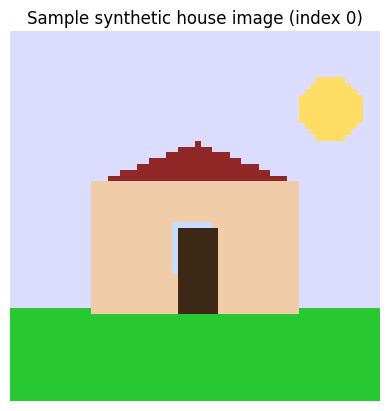

In [1]:
# Cell 1 — Environment setup & data preparation
from __future__ import annotations

import logging
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image, ImageDraw
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

RANDOM_STATE = 42
IMAGE_SIZE = 64
BATCH_SIZE = 32
NUM_EPOCHS = 12
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

logger.info("Using device: %s", DEVICE)

# --- Tabular: California Housing ---
housing = fetch_california_housing()
X_tabular = housing.data.astype(np.float32)  # shape: (N, 8)
y_prices = housing.target.astype(np.float32)  # shape: (N,) in $100k units
feature_names: List[str] = list(housing.feature_names)
n_samples = X_tabular.shape[0]

logger.info("California Housing: %s samples, %s features", n_samples, X_tabular.shape[1])

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_tabular).astype(np.float32)
y_scaled = scaler_y.fit_transform(y_prices.reshape(-1, 1)).astype(np.float32).ravel()

print("Feature names:", feature_names)
print(f"X_scaled shape: {X_scaled.shape} | y_scaled shape: {y_scaled.shape}")
print(f"Target (original) — min: {y_prices.min():.2f}, max: {y_prices.max():.2f}, mean: {y_prices.mean():.2f}")


def generate_synthetic_house_image(
    tabular_row: np.ndarray,
    index: int,
    size: int = IMAGE_SIZE,
) -> Image.Image:
    """
    Generate a deterministic $64 \times 64$ RGB 'house front' image from tabular features.

    Visual encoding (links image branch to structured data):
      - Sky brightness ← Latitude
      - Wall color intensity ← MedInc
      - Roof width ← AveRooms
      - Window count ← HouseAge (inverted)
      - Ground strip hue ← Longitude
    """
    med_inc, house_age, ave_rooms, ave_bedrms, population, ave_occup, latitude, longitude = tabular_row

    rng = np.random.default_rng(int(index) + 17)

    sky = int(np.clip(120 + latitude * 4, 80, 220))
    img = Image.new("RGB", (size, size), color=(sky, sky, min(255, sky + 40)))
    draw = ImageDraw.Draw(img)

    ground_color = (
        int(np.clip(60 + longitude, 40, 180)),
        int(np.clip(100 + med_inc * 20, 60, 200)),
        50,
    )
    draw.rectangle([0, int(size * 0.75), size, size], fill=ground_color)

    wall_intensity = int(np.clip(80 + med_inc * 35, 60, 240))
    wall_color = (wall_intensity, int(wall_intensity * 0.85), int(wall_intensity * 0.7))

    house_width = int(np.clip(size * 0.35 + ave_rooms * 3, size * 0.25, size * 0.55))
    house_height = int(size * 0.35)
    x0 = (size - house_width) // 2
    y0 = int(size * 0.75) - house_height

    # Roof (triangle)
    roof_peak = (size // 2, y0 - int(house_height * 0.35))
    draw.polygon(
        [(x0, y0), (x0 + house_width, y0), roof_peak],
        fill=(int(wall_intensity * 0.6), 40, 40),
    )
    draw.rectangle([x0, y0, x0 + house_width, y0 + house_height], fill=wall_color)

    n_windows = int(np.clip(5 - house_age / 10, 1, 4))
    for w in range(n_windows):
        wx = x0 + int((w + 1) * house_width / (n_windows + 1)) - 3
        wy = y0 + house_height // 3
        draw.rectangle([wx, wy, wx + 6, wy + 8], fill=(200, 220, 255))

    door_w = max(6, house_width // 6)
    draw.rectangle(
        [size // 2 - door_w // 2, y0 + house_height - 14, size // 2 + door_w // 2, y0 + house_height],
        fill=(60, 40, 20),
    )

    if rng.random() > 0.7:
        draw.ellipse([size - 14, 8, size - 4, 18], fill=(255, 220, 100))

    return img


# Preview one synthetic image
sample_img = generate_synthetic_house_image(X_tabular[0], index=0)
plt.imshow(sample_img)
plt.title("Sample synthetic house image (index 0)")
plt.axis("off")
plt.show()

IMAGE_TRANSFORM = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),  # shape: [3, 64, 64], values in [0, 1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

## Cell 2: Custom PyTorch Multimodal Dataset & DataLoaders

`__getitem__` returns `(tabular_tensor, image_tensor, price_tensor)` for each index.

In [2]:
# Cell 2 — Multimodal Dataset & DataLoaders


class MultimodalHousingDataset(Dataset):
    """Joint tabular + image dataset for housing price regression."""

    def __init__(
        self,
        tabular: np.ndarray,
        targets_scaled: np.ndarray,
        tabular_raw: np.ndarray,
        indices: np.ndarray,
        image_transform: transforms.Compose,
    ) -> None:
        self.tabular = tabular
        self.targets_scaled = targets_scaled
        self.tabular_raw = tabular_raw
        self.indices = indices
        self.image_transform = image_transform

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        real_idx = int(self.indices[idx])

        tabular_vec = torch.tensor(self.tabular[real_idx], dtype=torch.float32)  # shape: [8]

        pil_image = generate_synthetic_house_image(
            self.tabular_raw[real_idx],
            index=real_idx,
        )
        image_tensor = self.image_transform(pil_image)  # shape: [3, 64, 64]

        price_tensor = torch.tensor(
            self.targets_scaled[real_idx],
            dtype=torch.float32,
        )  # shape: scalar -> []

        return tabular_vec, image_tensor, price_tensor


all_idx = np.arange(n_samples)
train_idx, val_idx = train_test_split(
    all_idx,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

train_dataset = MultimodalHousingDataset(
    X_scaled, y_scaled, X_tabular, train_idx, IMAGE_TRANSFORM
)
val_dataset = MultimodalHousingDataset(
    X_scaled, y_scaled, X_tabular, val_idx, IMAGE_TRANSFORM
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

tab_b, img_b, price_b = next(iter(train_loader))
print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")
print(f"Tabular batch shape: {tab_b.shape}   # [batch, 8]")
print(f"Image batch shape:   {img_b.shape}   # [batch, 3, 64, 64]")
print(f"Target batch shape:  {price_b.shape} # [batch]")

Train samples: 16512 | Val samples: 4128
Tabular batch shape: torch.Size([32, 8])   # [batch, 8]
Image batch shape:   torch.Size([32, 3, 64, 64])   # [batch, 3, 64, 64]
Target batch shape:  torch.Size([32]) # [batch]


## Cell 3: Building the Multimodal Architecture (Feature Fusion Network)

CNN image branch + MLP tabular branch → `torch.cat` late fusion → regression head.

In [3]:
# Cell 3 — MultimodalRegressionNet


class MultimodalRegressionNet(nn.Module):
    """
    Late-fusion multimodal regressor.

    Tensor flow:
      image [B, 3, 64, 64] -> CNN -> [B, 2048]
      tabular [B, 8]       -> MLP -> [B, 32]
      cat -> [B, 2080] -> head -> [B, 1] -> squeeze -> [B]
    """

    def __init__(self, tabular_dim: int = 8, cnn_out_dim: int = 2048, mlp_out_dim: int = 32) -> None:
        super().__init__()

        # --- Image branch (CNN) ---
        self.cnn = nn.Sequential(
            # [B, 3, 64, 64]
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # -> [B, 32, 32, 32]
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # -> [B, 64, 16, 16]
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # -> [B, 128, 8, 8]
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # -> [B, 256, 4, 4]
        )
        self.cnn_flatten_dim = 256 * 4 * 4  # 2048
        self.cnn_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.cnn_flatten_dim, cnn_out_dim),
            nn.ReLU(inplace=True),
        )

        # --- Tabular branch (MLP) ---
        self.mlp = nn.Sequential(
            nn.Linear(tabular_dim, 64),  # [B, 8] -> [B, 64]
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(64),
            nn.Linear(64, mlp_out_dim),  # [B, 64] -> [B, 32]
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(mlp_out_dim),
        )

        fusion_dim = cnn_out_dim + mlp_out_dim  # 2048 + 32 = 2080

        # --- Regression head (fused) ---
        self.regression_head = nn.Sequential(
            nn.Linear(fusion_dim, 256),  # [B, 2080] -> [B, 256]
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 1),  # [B, 64] -> [B, 1]
        )

    def forward(
        self, tabular: torch.Tensor, image: torch.Tensor
    ) -> torch.Tensor:
        cnn_features = self.cnn_fc(self.cnn(image))  # [B, 2048]
        mlp_features = self.mlp(tabular)  # [B, 32]

        # Late fusion via concatenation along feature dimension (dim=1)
        fused = torch.cat([cnn_features, mlp_features], dim=1)  # [B, 2080]

        output = self.regression_head(fused)  # [B, 1]
        return output.squeeze(-1)  # [B]


model = MultimodalRegressionNet(tabular_dim=8).to(DEVICE)
with torch.no_grad():
    dummy_tab = torch.zeros(2, 8, device=DEVICE)
    dummy_img = torch.zeros(2, 3, 64, 64, device=DEVICE)
    dummy_out = model(dummy_tab, dummy_img)
print(model)
print(f"Dummy forward output shape: {dummy_out.shape}  # [batch]")

MultimodalRegressionNet(
  (cnn): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (cnn_fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=2048, bias=True)
    (2): ReLU(inplace=True)
  )
  (mlp): Sequential(
    (0): Linear

## Cell 4: Training Loop with Evaluation Tracking

Train for 12 epochs with `MSELoss`, Adam (`lr=1e-3`), logging train/validation loss each epoch.

In [4]:
# Cell 4 — Training loop

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

history: dict[str, list[float]] = {"train_loss": [], "val_loss": []}


def run_epoch(loader: DataLoader, training: bool) -> float:
    """One pass; returns mean MSE loss."""
    model.train(training)
    total_loss = 0.0
    n_batches = 0

    for tabular_batch, image_batch, price_batch in loader:
        tabular_batch = tabular_batch.to(DEVICE)
        image_batch = image_batch.to(DEVICE)
        price_batch = price_batch.to(DEVICE)

        if training:
            optimizer.zero_grad()

        preds = model(tabular_batch, image_batch)  # [B]
        loss = criterion(preds, price_batch)

        if training:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)


for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = run_epoch(train_loader, training=True)
    val_loss = run_epoch(val_loader, training=False)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(
        f"Epoch [{epoch:02d}/{NUM_EPOCHS}] | "
        f"Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}"
    )

logger.info("Training complete.")

Epoch [01/12] | Train MSE: 0.376224 | Val MSE: 0.293489
Epoch [02/12] | Train MSE: 0.299519 | Val MSE: 0.264673
Epoch [03/12] | Train MSE: 0.274934 | Val MSE: 0.255422
Epoch [04/12] | Train MSE: 0.267818 | Val MSE: 0.240643
Epoch [05/12] | Train MSE: 0.260758 | Val MSE: 0.295533
Epoch [06/12] | Train MSE: 0.246652 | Val MSE: 0.252280
Epoch [07/12] | Train MSE: 0.250306 | Val MSE: 0.216146
Epoch [08/12] | Train MSE: 0.240678 | Val MSE: 0.212218
Epoch [09/12] | Train MSE: 0.241851 | Val MSE: 0.237547
Epoch [10/12] | Train MSE: 0.234253 | Val MSE: 0.324564
Epoch [11/12] | Train MSE: 0.229675 | Val MSE: 0.229850
Epoch [12/12] | Train MSE: 0.232951 | Val MSE: 0.211998


## Cell 5: Comprehensive Regression Evaluation & Visualizations

Inverse-transform predictions to original price scale; report **MAE** and **RMSE**; plot loss curves and predicted vs. actual scatter.

VALIDATION METRICS (original price scale)
Mean Absolute Error (MAE):  0.3571
Root Mean Squared Error (RMSE): 0.5313
(Target is in $100,000 units — e.g. 2.5 ≈ $250,000)


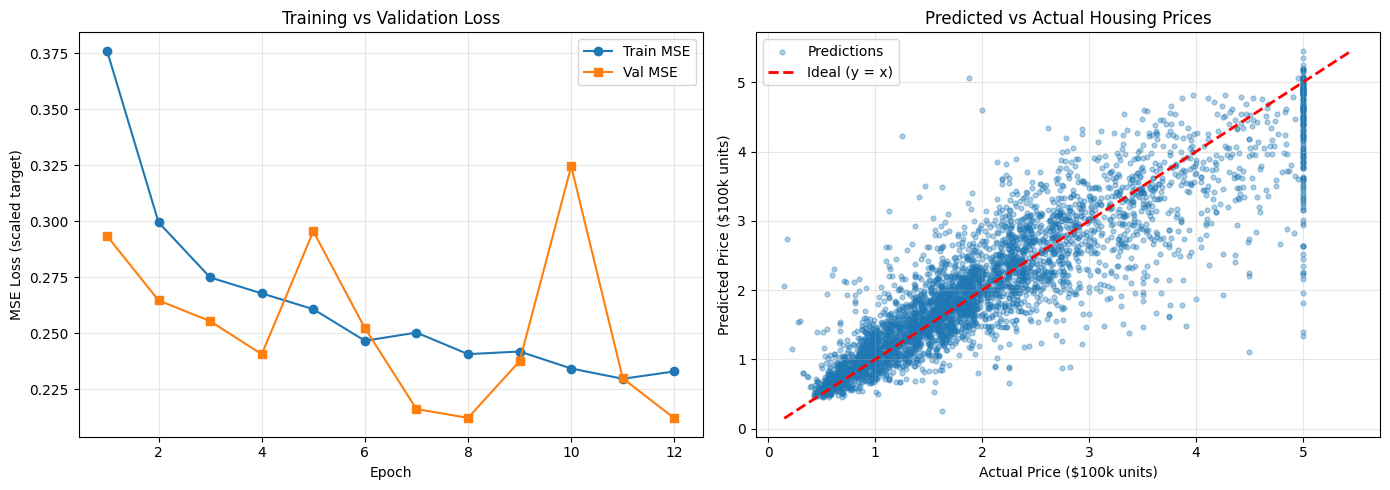

In [5]:
# Cell 5 — Evaluation & visualizations
from sklearn.metrics import mean_absolute_error, mean_squared_error

model.eval()
all_preds_scaled: list[float] = []
all_targets_scaled: list[float] = []

with torch.no_grad():
    for tabular_batch, image_batch, price_batch in val_loader:
        tabular_batch = tabular_batch.to(DEVICE)
        image_batch = image_batch.to(DEVICE)
        preds = model(tabular_batch, image_batch)
        all_preds_scaled.extend(preds.cpu().numpy().tolist())
        all_targets_scaled.extend(price_batch.numpy().tolist())

preds_scaled = np.array(all_preds_scaled, dtype=np.float32).reshape(-1, 1)
targets_scaled = np.array(all_targets_scaled, dtype=np.float32).reshape(-1, 1)

# Inverse scale to original target units ($100,000s)
preds_original = scaler_y.inverse_transform(preds_scaled).ravel()
targets_original = scaler_y.inverse_transform(targets_scaled).ravel()

mae = mean_absolute_error(targets_original, preds_original)
rmse = np.sqrt(mean_squared_error(targets_original, preds_original))

print("=" * 50)
print("VALIDATION METRICS (original price scale)")
print("=" * 50)
print(f"Mean Absolute Error (MAE):  {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print("(Target is in $100,000 units — e.g. 2.5 ≈ $250,000)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, NUM_EPOCHS + 1)
axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Train MSE")
axes[0].plot(epochs_range, history["val_loss"], marker="s", label="Val MSE")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss (scaled target)")
axes[0].set_title("Training vs Validation Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(targets_original, preds_original, alpha=0.35, s=12, label="Predictions")
min_p = min(targets_original.min(), preds_original.min())
max_p = max(targets_original.max(), preds_original.max())
axes[1].plot([min_p, max_p], [min_p, max_p], "r--", linewidth=2, label="Ideal (y = x)")
axes[1].set_xlabel("Actual Price ($100k units)")
axes[1].set_ylabel("Predicted Price ($100k units)")
axes[1].set_title("Predicted vs Actual Housing Prices")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()